Імпорт бібліотек 

In [6]:
import os
import re
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm import tqdm

Константи / налаштування експерименту


In [40]:
TRAIN_PATH = "../data/Corona_NLP_train.csv"
TEST_PATH = "../data/Corona_NLP_test.csv"
SINGLE_PATH = "../data/Corona_NLP.csv"  # якщо нема окремих файлів
TEXT_COL_CANDIDATES = ["OriginalTweet", "Original Tweet", "OriginalTweet_text", "text", "tweet", "tweet_text"]
LABEL_COL_CANDIDATES = ["Sentiment", "Label", "label", "sentiment"]

RANDOM_STATE = 42
TEST_SIZE = 0.2  # якщо використовується single file
W2V_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_EPOCHS = 10
PCA_COMPONENTS_LIST = [None, 50, 100, 200]  # None = без PCA

NLTK ресурси (завантаження)

In [31]:
nltk.download("punkt")
nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Утиліти: очистка, токенізація, агрегація векторів

In [42]:
def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"#", " ", s)
    s = re.sub(r"[^a-zA-Z0-9\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenize(text: str):
    toks = word_tokenize(str(text))
    toks = [t for t in toks if t.isalpha() and t not in STOPWORDS and len(t) > 1]
    return toks

def tweet_vector(tokens, model, vector_size):
    vecs = []
    for w in tokens:
        if w in model.wv:
            vecs.append(model.wv[w])
    if len(vecs) == 0:
        return np.zeros(vector_size, dtype=float)
    return np.mean(vecs, axis=0)

Допоміжна функція для пошуку колонки

In [43]:
def find_column(df_cols, candidates):
    for c in candidates:
        if c in df_cols:
            return c
    return None

Зчитування CSV (train/test або single + split)

In [46]:
if os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH):
    df_train = pd.read_csv(TRAIN_PATH, encoding="latin1")
    df_test  = pd.read_csv(TEST_PATH, encoding="latin1")
else:
    if os.path.exists(SINGLE_PATH):
        df_all = pd.read_csv(SINGLE_PATH, encoding="utf-8")
        txt_col = find_column(df_all.columns, TEXT_COL_CANDIDATES)
        lbl_col = find_column(df_all.columns, LABEL_COL_CANDIDATES)
        if txt_col is None or lbl_col is None:
            raise ValueError("Не вдалося знайти текстову або label колонку у single CSV. Перевірте імена колонок.")
        df_all = df_all[[txt_col, lbl_col]].dropna().rename(columns={txt_col: "text", lbl_col: "label"})
        df_train, df_test = train_test_split(df_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df_all["label"])
    else:
        # якщо немає single, пробуємо інші кодування для train/test
        tried = False
        for enc in ["cp1251", "latin1", "utf-8"]:
            try:
                if os.path.exists(TRAIN_PATH):
                    df_train = pd.read_csv(TRAIN_PATH, encoding=enc)
                else:
                    raise FileNotFoundError
                if os.path.exists(TEST_PATH):
                    df_test = pd.read_csv(TEST_PATH, encoding=enc)
                else:
                    raise FileNotFoundError
                tried = True
                break
            except Exception:
                continue
        if not tried:
            raise FileNotFoundError("Не знайдено вхідних файлів Corona_NLP_train/test або Corona_NLP.csv у теці.")



Стандартизація назв колонок (text, label) та короткий огляд

In [47]:
def standardize_columns(df):
    cols = df.columns
    txt_col = find_column(cols, TEXT_COL_CANDIDATES)
    lbl_col = find_column(cols, LABEL_COL_CANDIDATES)
    if txt_col is None or lbl_col is None:
        txt_guess = None
        lbl_guess = None
        for c in cols:
            cl = c.lower()
            if txt_guess is None and ("tweet" in cl or "text" in cl):
                txt_guess = c
            if lbl_guess is None and ("sent" in cl or "label" in cl or "target" in cl):
                lbl_guess = c
        if txt_guess is None or lbl_guess is None:
            raise ValueError(f"Не вдалося знайти текстову/label колонку у файлі. Стовпці: {list(cols)}")
        txt_col, lbl_col = txt_guess, lbl_guess
    df2 = df[[txt_col, lbl_col]].dropna().rename(columns={txt_col: "text", lbl_col: "label"})
    return df2

df_train = standardize_columns(df_train)
df_test = standardize_columns(df_test)

print("Train size after filtering:", len(df_train))
print("Test size after filtering:", len(df_test))
print("Some label values (train):", pd.Series(df_train["label"]).unique()[:20])

Train size after filtering: 41157
Test size after filtering: 3798
Some label values (train): ['Neutral' 'Positive' 'Extremely Negative' 'Negative' 'Extremely Positive']


Мапінг лейблів у 3 класи (Positive/Negative/Other)

In [48]:
def map_label_to_three(x):
    s = str(x).strip().lower()
    if s in ("positive", "pos", "p"):
        return "Positive"
    if s in ("negative", "neg", "n"):
        return "Negative"
    if "positive" in s or "extremely positive" in s or "very positive" in s:
        return "Positive"
    if "negative" in s or "extremely negative" in s or "very negative" in s:
        return "Negative"
    if s in ("neutral", "neut", "other", "mixed", "irrelevant"):
        return "Other"
    if s.isdigit():
        return s
    return "Other"

df_train["label3"] = df_train["label"].apply(map_label_to_three)
df_test["label3"] = df_test["label"].apply(map_label_to_three)

unique_train_labels = set(df_train["label3"].unique())
if any(str(x).isdigit() for x in unique_train_labels):
    def num_map(s):
        try:
            v = int(s)
            if v == 0:
                return "Negative"
            if v == 2:
                return "Positive"
            return "Other"
        except:
            return s
    df_train["label3"] = df_train["label3"].apply(num_map)
    df_test["label3"] = df_test["label3"].apply(num_map)

print("Mapped label distribution (train):")
print(df_train["label3"].value_counts())

Mapped label distribution (train):
label3
Positive    18046
Negative    15398
Other        7713
Name: count, dtype: int64


Чистка тексту, токенізація та фільтрація порожніх

In [49]:
df_train["clean"] = df_train["text"].apply(clean_text)
df_train["tokens"] = df_train["clean"].apply(tokenize)
df_test["clean"] = df_test["text"].apply(clean_text)
df_test["tokens"] = df_test["clean"].apply(tokenize)

# Видалимо рядки без токенів
df_train = df_train[df_train["tokens"].map(len) > 0].reset_index(drop=True)
df_test = df_test[df_test["tokens"].map(len) > 0].reset_index(drop=True)
print("After token filtering - train:", len(df_train), " test:", len(df_test))

After token filtering - train: 41123  test: 3796


Навчання Word2Vec на комбінованому корпусі і збереження моделі

In [50]:
sentences = list(df_train["tokens"]) + list(df_test["tokens"])
w2v_model = Word2Vec(sentences=sentences, vector_size=W2V_SIZE, window=W2V_WINDOW,
                     min_count=W2V_MIN_COUNT, workers=4, epochs=W2V_EPOCHS, seed=RANDOM_STATE)
joblib.dump(w2v_model, "w2v_model.joblib")
print("Word2Vec trained. vocab size:", len(w2v_model.wv.index_to_key))

Word2Vec trained. vocab size: 20994


Побудова матриць ознак (mean pooling) та LabelEncoder


In [51]:
X_train = np.vstack(df_train["tokens"].apply(lambda t: tweet_vector(t, w2v_model, W2V_SIZE)).values)
X_test = np.vstack(df_test["tokens"].apply(lambda t: tweet_vector(t, w2v_model, W2V_SIZE)).values)
y_train_raw = df_train["label3"].values
y_test_raw = df_test["label3"].values

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)

# Уникаємо помилки, якщо в тесті є label, що не траплялись у train:
# замінюємо unseen в тесті на "Other" якщо потрібно
seen_labels = set(le.classes_)
y_test_safe = []
for lab in y_test_raw:
    if lab in seen_labels:
        y_test_safe.append(lab)
    else:
        y_test_safe.append("Other")
y_test = le.transform(y_test_safe)

print("Classes (LabelEncoder):", dict(enumerate(le.classes_)))

Classes (LabelEncoder): {0: 'Negative', 1: 'Other', 2: 'Positive'}


Ініціалізація моделей

In [52]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "LinearSVM": LinearSVC(verbose=0, max_iter=10000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB()
}

Функція для збереження / відображення матриці плутанини

In [53]:
def plot_and_save_cm(cm, labels, title, fname=None, show=False):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    if fname:
        plt.savefig(fname)
    if show:
        plt.show()
    plt.close()

Основний експеримент: PCA варіанти × моделі, збереження pipeline'ів і результатів


Experiment: NoPCA

Training model: LogisticRegression with NoPCA


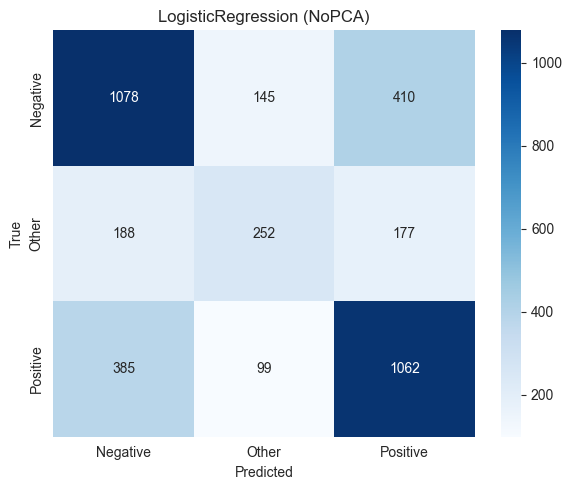

Model LogisticRegression trained & saved: pipeline_LogisticRegression_NoPCA.joblib; accuracy=0.6301
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6529376135675349, 'recall': 0.6601347213717085, 'f1-score': 0.6565164433617539, 'support': 1633.0}, 'Other': {'precision': 0.5080645161290323, 'recall': 0.40842787682333875, 'f1-score': 0.4528301886792453, 'support': 617.0}, 'Positive': {'precision': 0.6440266828380837, 'recall': 0.6869340232858991, 'f1-score': 0.6647887323943662, 'support': 1546.0}, 'accuracy': 0.6301369863013698, 'macro avg': {'precision': 0.6016762708448836, 'recall': 0.5851655404936488, 'f1-score': 0.5913784548117884, 'support': 3796.0}, 'weighted avg': {'precision': 0.6257608485445403, 'recall': 0.6301369863013698, 'f1-score': 0.6267784401229001, 'support': 3796.0}}

Training model: LinearSVM with NoPCA


D:\ML\lab3\.venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [ ]:
results = []
for n_comp in PCA_COMPONENTS_LIST:
    pca_descr = "NoPCA" if n_comp is None else f"PCA_{n_comp}"
    print("\n" + "="*40)
    print("Experiment:", pca_descr)
    print("="*40)
    for mname, mobj in models.items():
        print(f"\nTraining model: {mname} with {pca_descr}")
        steps = []
        if n_comp is not None:
            n_use = min(n_comp, X_train.shape[1])
            steps.append(("pca", PCA(n_components=n_use, random_state=RANDOM_STATE)))
        steps.append(("clf", mobj))
        pipeline = Pipeline(steps)

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        row = {"model": mname, "pca": "None" if n_comp is None else n_comp, "accuracy": acc}
        for cls in le.classes_:
            cls_dict = report.get(cls, {"precision":0,"recall":0,"f1-score":0,"support":0})
            row[f"{cls}_precision"] = cls_dict["precision"]
            row[f"{cls}_recall"] = cls_dict["recall"]
            row[f"{cls}_f1"] = cls_dict["f1-score"]
            row[f"{cls}_support"] = cls_dict.get("support", 0)
        results.append(row)

        fname = f"cm_{mname}_{pca_descr}.png"
        if mname == "LogisticRegression":
            plot_and_save_cm(cm, labels=le.classes_, title=f"{mname} ({pca_descr})", fname=None, show=True)
        else:
            plot_and_save_cm(cm, labels=le.classes_, title=f"{mname} ({pca_descr})", fname=fname, show=False)
            print("Saved CM:", fname)

        joblib.dump(pipeline, f"pipeline_{mname}_{pca_descr}.joblib")
        print(f"Model {mname} trained & saved: pipeline_{mname}_{pca_descr}.joblib; accuracy={acc:.4f}")
        print("Precision / Recall / F1-score per class:")
        print(report)

Збереження таблиці результатів

In [ ]:
results_df = pd.DataFrame(results).sort_values(by=["model", "pca"]).reset_index(drop=True)
results_df.to_csv("results_table.csv", index=False)
print("\nSaved results_table.csv")
print(results_df)

Функції для прогнозу на новому тексті

In [ ]:
def preprocess_and_vectorize(text, w2v_model, vector_size=W2V_SIZE):
    ct = clean_text(text)
    tokens = tokenize(ct)
    return tweet_vector(tokens, w2v_model, vector_size).reshape(1, -1)

def predict_new_text(text, pipeline_path, w2v_model, label_encoder):
    pipeline = joblib.load(pipeline_path)
    vec = preprocess_and_vectorize(text, w2v_model)
    pred = pipeline.predict(vec)
    return label_encoder.inverse_transform(pred)[0]